# Tarea 4: PyTorch

**Alumno: Edgar Cano Orozco**

# Tarea Clase 7 — PyTorch: Autograd, nn.Module y MLP

Este notebook desarrolla la tarea de la Clase 7 del Módulo 1.

Objetivos:

1. Implementar un training loop desde cero usando autograd puro.
2. Reimplementar el mismo problema usando `nn.Module` y `torch.optim`.
3. Explorar el funcionamiento de autograd comparando gradientes analíticos vs gradientes automáticos.
4. Mostrar el efecto de olvidar `optimizer.zero_grad()`.
5. Entrenar un MLP pequeño para clasificar el dataset `make_moons`.
6. Registrar el entrenamiento del MLP en MLflow como bonus.

In [82]:
from __future__ import annotations

import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [4]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0


In [5]:
def get_device() -> torch.device:
    """Selecciona el mejor device disponible."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
print(f"Device seleccionado: {DEVICE}")

Device seleccionado: mps


In [7]:
# función auxiliar para graficar loss
def plot_loss_curve(
    losses: list[float],
    title: str = "Convergencia del loss",
    xlabel: str = "Epoch",
    ylabel: str = "Loss",
) -> None:
    """Grafica la evolución del loss durante entrenamiento."""
    plt.figure(figsize=(8, 5))
    plt.plot(losses)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [37]:
@dataclass
class SinTrainingConfig:
    """Configuración del experimento y = sin(w*x + b)."""

    n_samples: int = 300
    true_w: float = 1.3
    true_b: float = 0.4
    noise_std: float = 0.05
    learning_rate: float = 0.05
    n_epochs: int = 5_000


config = SinTrainingConfig()
config

SinTrainingConfig(n_samples=300, true_w=1.3, true_b=0.4, noise_std=0.05, learning_rate=0.05, n_epochs=5000)

# Parte 1 — Autograd puro

En esta sección entrenamos dos parámetros escalares `w` y `b` para aproximar la función:

$$
y = \sin(w x + b)
$$

El dataset sintético se genera usando los valores verdaderos:

- `w* = 1.3`
- `b* = 0.4`

El entrenamiento se implementa desde cero usando autograd, sin `nn.Module` y sin `torch.optim`.

In [38]:
x = torch.linspace(-3, 3, config.n_samples).reshape(-1, 1).to(DEVICE)

noise = config.noise_std * torch.randn_like(x)

y = torch.sin(config.true_w * x + config.true_b) + noise

x.shape, y.shape

(torch.Size([300, 1]), torch.Size([300, 1]))

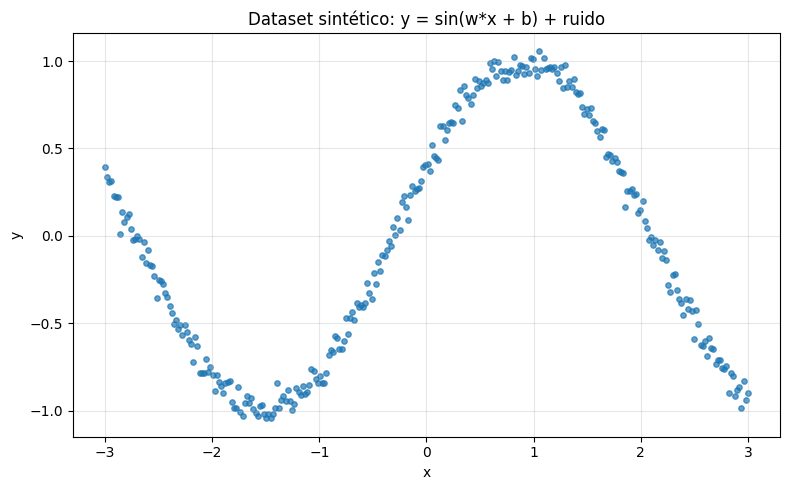

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(
    x.cpu().numpy(),
    y.cpu().numpy(),
    s=15,
    alpha=0.7,
)
plt.title("Dataset sintético: y = sin(w*x + b) + ruido")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
w = torch.randn((), device=DEVICE, requires_grad=True)
b = torch.randn((), device=DEVICE, requires_grad=True)

print(f"w inicial: {w.item():.4f}")
print(f"b inicial: {b.item():.4f}")

w inicial: -1.5057
b inicial: 0.2223


In [ ]:
losses = []

start_time = time.perf_counter()

for _epoch in range(config.n_epochs):
    # Forward pass
    y_pred = torch.sin(w * x + b)

    # Loss MSE
    loss = torch.mean((y_pred - y) ** 2)

    # Backward pass
    loss.backward()

    # Actualización manual de parámetros
    with torch.no_grad():
        w -= config.learning_rate * w.grad
        b -= config.learning_rate * b.grad

        w.grad.zero_()
        b.grad.zero_()

    losses.append(loss.item())

elapsed_time = time.perf_counter() - start_time

print(f"Tiempo de entrenamiento: {elapsed_time:.4f} segundos")
print(f"Loss final: {losses[-1]:.6f}")
print(f"w aprendido: {w.item():.4f}")
print(f"b aprendido: {b.item():.4f}")
print(f"w verdadero: {config.true_w:.4f}")
print(f"b verdadero: {config.true_b:.4f}")

Tiempo de entrenamiento: 1.5635 segundos
Loss final: 0.002345
w aprendido: -1.3035
b aprendido: 2.7394
w verdadero: 1.3000
b verdadero: 0.4000


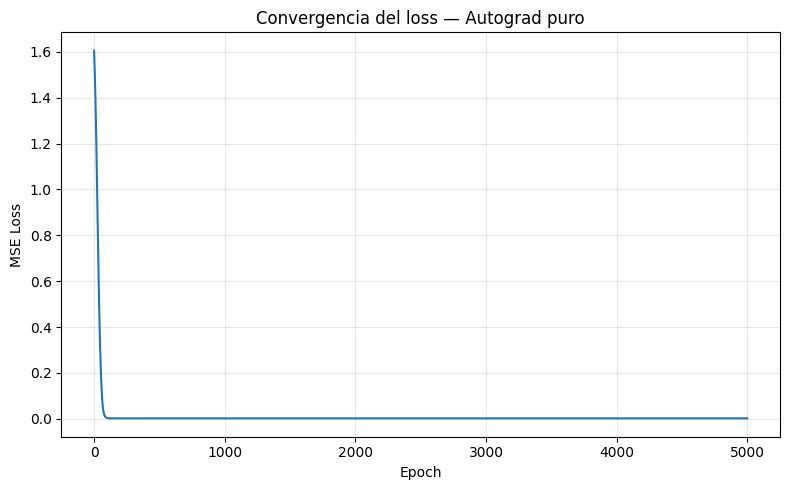

In [42]:
plot_loss_curve(
    losses,
    title="Convergencia del loss — Autograd puro",
    xlabel="Epoch",
    ylabel="MSE Loss",
)

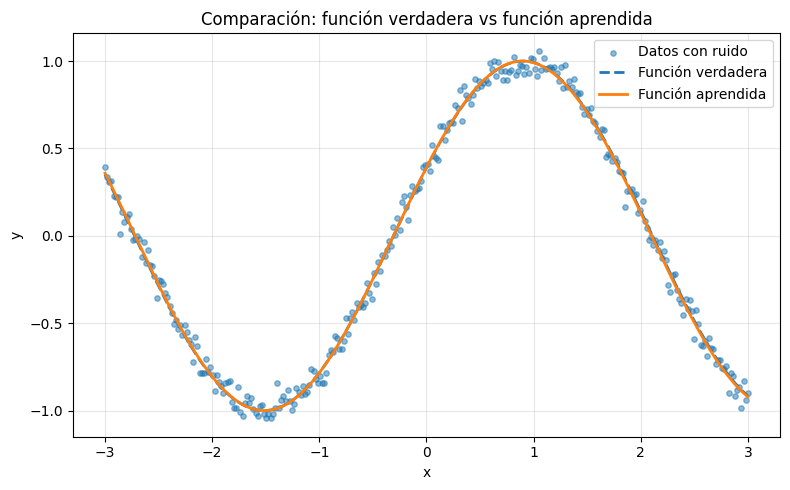

In [43]:
with torch.no_grad():
    y_learned = torch.sin(w * x + b)
    y_true = torch.sin(config.true_w * x + config.true_b)

plt.figure(figsize=(8, 5))

plt.scatter(
    x.cpu().numpy(),
    y.cpu().numpy(),
    s=15,
    alpha=0.5,
    label="Datos con ruido",
)

plt.plot(
    x.cpu().numpy(),
    y_true.cpu().numpy(),
    linestyle="--",
    linewidth=2,
    label="Función verdadera",
)

plt.plot(
    x.cpu().numpy(),
    y_learned.cpu().numpy(),
    linewidth=2,
    label="Función aprendida",
)

plt.title("Comparación: función verdadera vs función aprendida")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
equivalent_w = -config.true_w
equivalent_b = np.pi - config.true_b

print(f"w equivalente esperado: {equivalent_w:.4f}")
print(f"b equivalente esperado: {equivalent_b:.4f}")

print(f"w aprendido: {w.item():.4f}")
print(f"b aprendido: {b.item():.4f}")

w equivalente esperado: -1.3000
b equivalente esperado: 2.7416
w aprendido: -1.3035
b aprendido: 2.7394


### Conclusión de la Parte 1

El entrenamiento con autograd puro logró reducir el loss hasta un valor muy bajo, lo que indica que el modelo aprendió correctamente la forma de la función objetivo.

Aunque los parámetros aprendidos no coinciden directamente con `w* = 1.3` y `b* = 0.4`, sí corresponden a una solución equivalente debido a la simetría de la función seno:

$$
\sin(w x + b) = \sin(-w x + \pi - b)
$$

Por ello, una solución cercana a `w = -1.3` y `b = π - 0.4 ≈ 2.7416` representa prácticamente la misma curva que la función verdadera.

Esto muestra que el problema no identifica de forma única los parámetros, pero sí permite aprender una función predictiva correcta.

# Parte 2 — Reimplementación con nn.Module + torch.optim

En esta sección resolvemos el mismo problema de la Parte 1, pero ahora usando las abstracciones estándar de PyTorch:

- `nn.Module` para definir el modelo.
- `nn.Parameter` para registrar parámetros entrenables.
- `torch.optim` para actualizar los parámetros automáticamente.

El objetivo es comparar esta implementación contra el entrenamiento manual con autograd puro.

In [54]:
class SinModel(nn.Module):
    """Modelo y = sin(w*x + b) con parámetros entrenables."""

    def __init__(self, w_init: float = 0.8, b_init: float = 0.0) -> None:
        super().__init__()
        self.w = nn.Parameter(torch.tensor(w_init, dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor(b_init, dtype=torch.float32))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.w * x + self.b)

In [61]:
module_model = SinModel(w_init=0.8, b_init=0.0).to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    module_model.parameters(),
    lr=0.01,
)

print(f"w inicial: {module_model.w.item():.4f}")
print(f"b inicial: {module_model.b.item():.4f}")

w inicial: 0.8000
b inicial: 0.0000


In [ ]:
module_losses = []

start_time = time.perf_counter()

for _epoch in range(config.n_epochs):
    # 1. Limpiar gradientes
    optimizer.zero_grad()

    # 2. Forward pass
    y_pred = module_model(x)

    # 3. Calcular loss
    loss = criterion(y_pred, y)

    # 4. Backward pass
    loss.backward()

    # 5. Actualizar parámetros
    optimizer.step()

    module_losses.append(loss.item())

module_elapsed_time = time.perf_counter() - start_time

print(f"Tiempo de entrenamiento: {module_elapsed_time:.4f} segundos")
print(f"Loss final: {module_losses[-1]:.6f}")
print(f"w aprendido: {module_model.w.item():.4f}")
print(f"b aprendido: {module_model.b.item():.4f}")
print(f"w verdadero: {config.true_w:.4f}")
print(f"b verdadero: {config.true_b:.4f}")

Tiempo de entrenamiento: 2.0495 segundos
Loss final: 0.002345
w aprendido: 1.3035
b aprendido: 0.4022
w verdadero: 1.3000
b verdadero: 0.4000


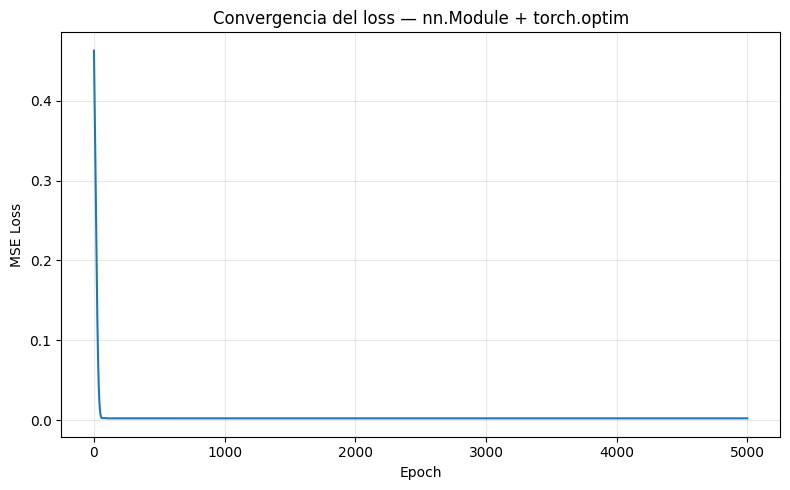

In [63]:
plot_loss_curve(
    module_losses,
    title="Convergencia del loss — nn.Module + torch.optim",
    xlabel="Epoch",
    ylabel="MSE Loss",
)

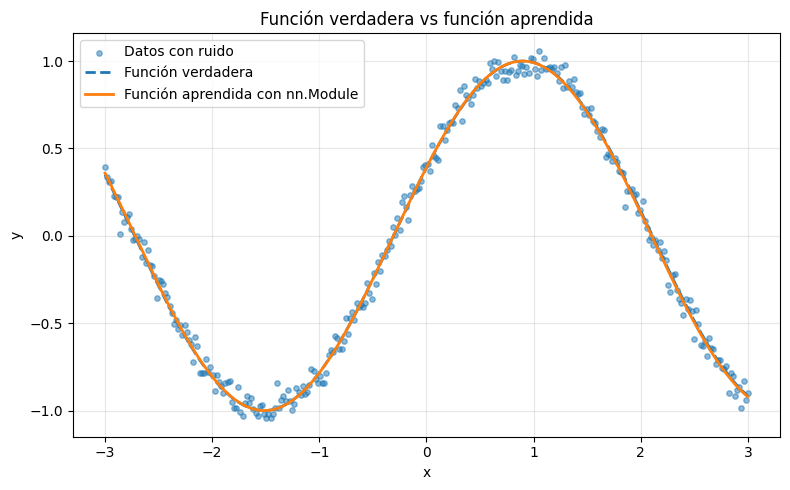

In [64]:
with torch.no_grad():
    y_module_learned = module_model(x)
    y_true = torch.sin(config.true_w * x + config.true_b)

plt.figure(figsize=(8, 5))

plt.scatter(
    x.cpu().numpy(),
    y.cpu().numpy(),
    s=15,
    alpha=0.5,
    label="Datos con ruido",
)

plt.plot(
    x.cpu().numpy(),
    y_true.cpu().numpy(),
    linestyle="--",
    linewidth=2,
    label="Función verdadera",
)

plt.plot(
    x.cpu().numpy(),
    y_module_learned.cpu().numpy(),
    linewidth=2,
    label="Función aprendida con nn.Module",
)

plt.title("Función verdadera vs función aprendida")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
comparison_results = {
    "implementation": [
        "Autograd puro",
        "nn.Module + torch.optim",
    ],
    "final_loss": [
        losses[-1],
        module_losses[-1],
    ],
    "training_time_seconds": [
        elapsed_time,
        module_elapsed_time,
    ],
    "final_w": [
        w.item(),
        module_model.w.item(),
    ],
    "final_b": [
        b.item(),
        module_model.b.item(),
    ],
}

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,implementation,final_loss,training_time_seconds,final_w,final_b
0,Autograd puro,0.002345,1.563550,-1.303529,2.739385
1,nn.Module + torch.optim,0.002345,2.049458,1.303528,0.402206


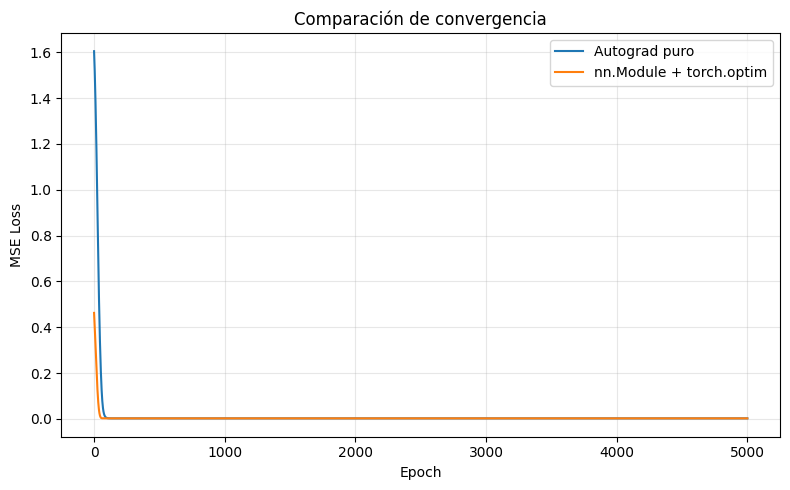

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(losses, label="Autograd puro")
plt.plot(module_losses, label="nn.Module + torch.optim")

plt.title("Comparación de convergencia")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusión de la Parte 2

La reimplementación con `nn.Module` y `torch.optim` logró ajustar correctamente la función objetivo:

$$
y = \sin(w x + b)
$$

Después de inicializar los parámetros en una región razonable, el modelo obtuvo un loss final muy bajo y parámetros aprendidos muy cercanos a los valores verdaderos:

- `w` aprendido ≈ 1.3035, contra `w* = 1.3000`
- `b` aprendido ≈ 0.4022, contra `b* = 0.4000`
- Loss final ≈ 0.002345

Esto confirma que la implementación con `nn.Module` no cambia la lógica matemática del entrenamiento: PyTorch sigue construyendo un grafo computacional, calculando gradientes con `loss.backward()` y actualizando los parámetros con base en esos gradientes. La diferencia principal es que ahora el código queda más organizado y escalable.

En la Parte 1 actualizamos manualmente los parámetros con:

```python
w -= learning_rate * w.grad
b -= learning_rate * b.grad

# Parte 3 — Exploración de autograd

En esta sección definimos una función escalar `f(x)` sobre un tensor de dimensión 2 y comparamos:

1. El gradiente calculado automáticamente por PyTorch usando `autograd`.
2. El gradiente calculado manualmente de forma analítica.

El objetivo es verificar que ambos gradientes coinciden dentro de una tolerancia de `1e-5`.

La función que vamos a definir es:

$$f(x) = mean(sin(x)  x^2 + exp(0.3x) + log(1 + x^2))$$

In [69]:
def custom_function(x: torch.Tensor) -> torch.Tensor:
    """Función escalar con varias operaciones diferenciables."""
    return torch.mean(torch.sin(x) * x**2 + torch.exp(0.3 * x) + torch.log(1 + x**2))

In [70]:
def analytical_gradient(x: torch.Tensor) -> torch.Tensor:
    """Gradiente analítico de custom_function respecto a x."""
    grad = (
        torch.cos(x) * x**2
        + 2 * x * torch.sin(x)
        + 0.3 * torch.exp(0.3 * x)
        + (2 * x) / (1 + x**2)
    )

    return grad / x.numel()

In [72]:
x_grad = torch.randn(
    4,
    3,
    dtype=torch.float64,
    requires_grad=True,
)

x_grad

tensor([[ 1.1103, -1.6898, -0.9890],
        [ 0.9580,  1.3221,  0.8172],
        [-0.7658, -0.7506,  1.3525],
        [ 0.6863, -0.3278,  0.7950]], dtype=torch.float64, requires_grad=True)

In [74]:
f_value = custom_function(x_grad)

f_value.backward()

autograd_grad = x_grad.grad

autograd_grad

tensor([[0.1055, 0.0512, 0.0774],
        [0.0763, 0.1493, 0.0022],
        [0.1651, 0.0357, 0.1423],
        [0.0862, 0.1646, 0.2487]], dtype=torch.float64)

In [75]:
manual_grad = analytical_gradient(x_grad.detach())

manual_grad

tensor([[0.1055, 0.0512, 0.0774],
        [0.0763, 0.1493, 0.0022],
        [0.1651, 0.0357, 0.1423],
        [0.0862, 0.1646, 0.2487]], dtype=torch.float64)

In [76]:
max_abs_diff = torch.max(torch.abs(autograd_grad - manual_grad)).item()

are_close = torch.allclose(
    autograd_grad,
    manual_grad,
    atol=1e-5,
)

print(f"Máxima diferencia absoluta: {max_abs_diff:.10f}")
print(f"¿Gradientes coinciden con tolerancia 1e-5?: {are_close}")

Máxima diferencia absoluta: 0.0000000000
¿Gradientes coinciden con tolerancia 1e-5?: True


In [77]:
gradient_comparison_df = pd.DataFrame(
    {
        "x": x_grad.detach().flatten().numpy(),
        "grad_autograd": autograd_grad.detach().flatten().numpy(),
        "grad_analytical": manual_grad.detach().flatten().numpy(),
        "absolute_difference": (autograd_grad.detach() - manual_grad.detach())
        .abs()
        .flatten()
        .numpy(),
    }
)

gradient_comparison_df

,x,grad_autograd,grad_analytical,absolute_difference
0,0.336690,0.105513,0.105513,0.000000e+00
1,0.128809,0.051232,0.051232,6.938894e-18
2,0.234462,0.077397,0.077397,1.387779e-17
3,0.230333,0.076312,0.076312,1.387779e-17
4,-1.122856,0.149258,0.149258,0.000000e+00
5,-0.186328,0.002224,0.002224,1.734723e-18
6,2.208201,0.165067,0.165067,0.000000e+00
7,-0.637997,0.035651,0.035651,6.938894e-18
8,0.461657,0.142313,0.142313,2.775558e-17
9,0.267351,0.086190,0.086190,2.775558e-17


# Parte 4 — Efecto de olvidar optimizer.zero_grad()

En PyTorch, los gradientes se acumulan por defecto. Esto significa que cada vez que llamamos a `loss.backward()`, el gradiente calculado se suma al gradiente anterior.

En un training loop estándar, normalmente queremos que cada actualización use únicamente el gradiente del batch o epoch actual. Para eso usamos:

```python
optimizer.zero_grad()


---

## 4.2 Función auxiliar para entrenar con o sin `zero_grad`

Usaremos el mismo problema de la Parte 2:

```python
y = sin(w*x + b)

In [ ]:
def train_sin_model_zero_grad_experiment(
    use_zero_grad: bool,
    n_epochs: int = 500,
    learning_rate: float = 0.01,
) -> tuple[SinModel, list[float]]:
    """Entrena SinModel con o sin optimizer.zero_grad()."""
    model = SinModel(w_init=0.8, b_init=0.0).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
    )

    experiment_losses = []

    for _epoch in range(n_epochs):
        if use_zero_grad:
            optimizer.zero_grad()

        y_pred = model(x)
        loss = criterion(y_pred, y)

        loss.backward()
        optimizer.step()

        experiment_losses.append(loss.item())

    return model, experiment_losses

In [80]:
correct_model, correct_losses = train_sin_model_zero_grad_experiment(
    use_zero_grad=True,
    n_epochs=500,
    learning_rate=0.01,
)

wrong_model, wrong_losses = train_sin_model_zero_grad_experiment(
    use_zero_grad=False,
    n_epochs=500,
    learning_rate=0.01,
)

print("Entrenamiento correcto")
print(f"Loss final: {correct_losses[-1]:.6f}")
print(f"w aprendido: {correct_model.w.item():.4f}")
print(f"b aprendido: {correct_model.b.item():.4f}")

print("\nEntrenamiento sin zero_grad")
print(f"Loss final: {wrong_losses[-1]:.6f}")
print(f"w aprendido: {wrong_model.w.item():.4f}")
print(f"b aprendido: {wrong_model.b.item():.4f}")

Entrenamiento correcto
Loss final: 0.002347
w aprendido: 1.3035
b aprendido: 0.4004

Entrenamiento sin zero_grad
Loss final: 0.184887
w aprendido: 1.2735
b aprendido: 1.0025


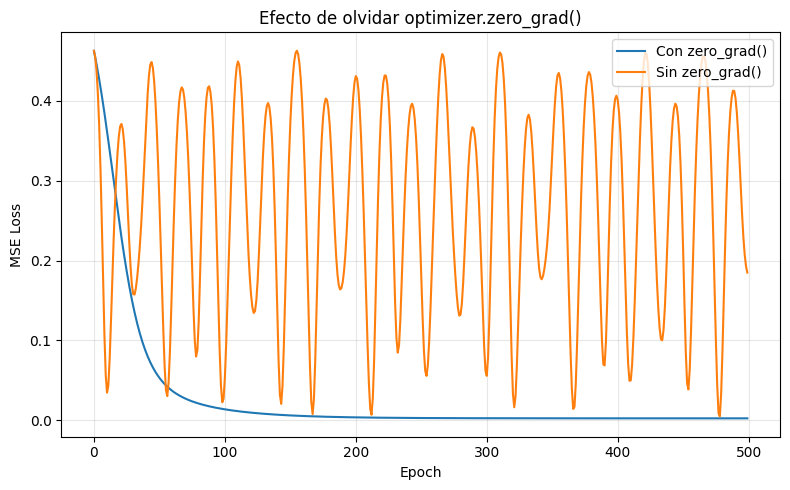

In [81]:
plt.figure(figsize=(8, 5))

plt.plot(correct_losses, label="Con zero_grad()")
plt.plot(wrong_losses, label="Sin zero_grad()")

plt.title("Efecto de olvidar optimizer.zero_grad()")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusión de la Parte 4

En esta sección se compararon dos entrenamientos: uno usando correctamente `optimizer.zero_grad()` y otro omitiéndolo.

El experimento muestra que, cuando no se limpian los gradientes, PyTorch acumula los valores de `.grad` en cada llamada a `loss.backward()`. Esto significa que la actualización de parámetros deja de depender únicamente del gradiente de la iteración actual y empieza a mezclar información de iteraciones anteriores.

Este comportamiento puede provocar que el entrenamiento se vuelva inestable, que el loss oscile, que deje de mejorar o que incluso aumente. La severidad del problema depende del learning rate, la inicialización y la forma de la función de pérdida.

Por eso, el patrón estándar de entrenamiento en PyTorch incluye siempre la limpieza de gradientes antes de calcular el nuevo backward pass:

```python
optimizer.zero_grad()
y_pred = model(x)
loss = criterion(y_pred, y)
loss.backward()
optimizer.step()

# Parte 5 — MLP para clasificación binaria con make_moons

En esta sección entrenamos una red neuronal pequeña para clasificar el dataset sintético `make_moons`.

Este dataset no es linealmente separable, por lo que un modelo lineal simple no sería suficiente. Usaremos un MLP con tres capas lineales y activaciones ReLU para aprender una frontera de decisión no lineal.

El modelo se entrenará con:

- `nn.BCEWithLogitsLoss`, adecuada para clasificación binaria.
- `torch.optim.Adam`, un optimizador adaptativo común en deep learning.

In [83]:
X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.2,
    random_state=SEED,
)

print(f"X shape: {X_moons.shape}")
print(f"y shape: {y_moons.shape}")
print(f"Clases: {np.unique(y_moons)}")

X shape: (500, 2)
y shape: (500,)
Clases: [0 1]


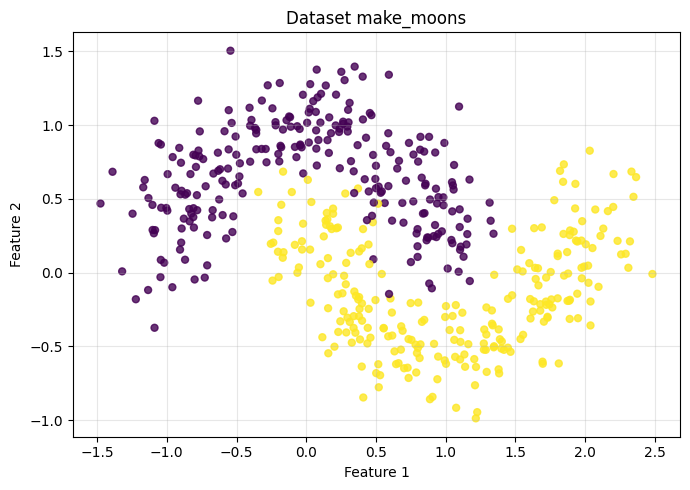

In [84]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X_moons[:, 0],
    X_moons[:, 1],
    c=y_moons,
    s=25,
    alpha=0.8,
)

plt.title("Dataset make_moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons,
    y_moons,
    test_size=0.2,
    stratify=y_moons,
    random_state=SEED,
)

print(f"Train: {X_train_moons.shape}")
print(f"Test: {X_test_moons.shape}")

Train: (400, 2)
Test: (100, 2)


In [86]:
scaler_moons = StandardScaler()

X_train_moons_scaled = scaler_moons.fit_transform(X_train_moons)
X_test_moons_scaled = scaler_moons.transform(X_test_moons)

In [87]:
X_train_tensor = torch.tensor(
    X_train_moons_scaled,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train_moons.reshape(-1, 1),
    dtype=torch.float32,
)

X_test_tensor = torch.tensor(
    X_test_moons_scaled,
    dtype=torch.float32,
)

y_test_tensor = torch.tensor(
    y_test_moons.reshape(-1, 1),
    dtype=torch.float32,
)

X_train_tensor.shape, y_train_tensor.shape

(torch.Size([400, 2]), torch.Size([400, 1]))

In [88]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
)

In [89]:
class MoonMLP(nn.Module):
    """MLP pequeño para clasificación binaria en make_moons."""

    def __init__(self, input_dim: int = 2, hidden_dim: int = 16) -> None:
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [90]:
torch.manual_seed(SEED)

moon_model = MoonMLP(
    input_dim=2,
    hidden_dim=16,
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    moon_model.parameters(),
    lr=0.01,
)

moon_model

MoonMLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [91]:
@torch.no_grad()
def binary_accuracy_from_logits(
    logits: torch.Tensor,
    y_true: torch.Tensor,
) -> float:
    """Calcula accuracy para clasificación binaria usando logits."""
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()

    return (predictions == y_true).float().mean().item()

In [ ]:
n_epochs = 300

moon_history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}

start_time = time.perf_counter()

for _epoch in range(n_epochs):
    moon_model.train()

    train_loss_sum = 0.0
    train_acc_sum = 0.0
    train_samples = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        logits = moon_model(x_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        batch_size = x_batch.size(0)
        train_loss_sum += loss.item() * batch_size
        train_acc_sum += binary_accuracy_from_logits(logits, y_batch) * batch_size
        train_samples += batch_size

    train_loss = train_loss_sum / train_samples
    train_accuracy = train_acc_sum / train_samples

    moon_model.eval()

    test_loss_sum = 0.0
    test_acc_sum = 0.0
    test_samples = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = moon_model(x_batch)
            loss = criterion(logits, y_batch)

            batch_size = x_batch.size(0)
            test_loss_sum += loss.item() * batch_size
            test_acc_sum += binary_accuracy_from_logits(logits, y_batch) * batch_size
            test_samples += batch_size

    test_loss = test_loss_sum / test_samples
    test_accuracy = test_acc_sum / test_samples

    moon_history["train_loss"].append(train_loss)
    moon_history["train_accuracy"].append(train_accuracy)
    moon_history["test_loss"].append(test_loss)
    moon_history["test_accuracy"].append(test_accuracy)

    if (_epoch + 1) % 50 == 0:
        print(
            f"Epoch {_epoch + 1:03d}/{n_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_accuracy:.4f} | "
            f"test_loss={test_loss:.4f} | "
            f"test_acc={test_accuracy:.4f}"
        )

elapsed_time_moons = time.perf_counter() - start_time

print(f"\nTiempo de entrenamiento: {elapsed_time_moons:.4f} segundos")
print(f"Accuracy final train: {moon_history['train_accuracy'][-1]:.4f}")
print(f"Accuracy final test: {moon_history['test_accuracy'][-1]:.4f}")

Epoch 050/300 | train_loss=0.0312 | train_acc=0.9825 | test_loss=0.0409 | test_acc=0.9700
Epoch 100/300 | train_loss=0.0305 | train_acc=0.9850 | test_loss=0.0468 | test_acc=0.9800
Epoch 150/300 | train_loss=0.0241 | train_acc=0.9850 | test_loss=0.0536 | test_acc=0.9800
Epoch 200/300 | train_loss=0.0229 | train_acc=0.9850 | test_loss=0.0478 | test_acc=0.9700
Epoch 250/300 | train_loss=0.0222 | train_acc=0.9875 | test_loss=0.0493 | test_acc=0.9700
Epoch 300/300 | train_loss=0.0196 | train_acc=0.9875 | test_loss=0.0536 | test_acc=0.9700

Tiempo de entrenamiento: 7.3008 segundos
Accuracy final train: 0.9875
Accuracy final test: 0.9700


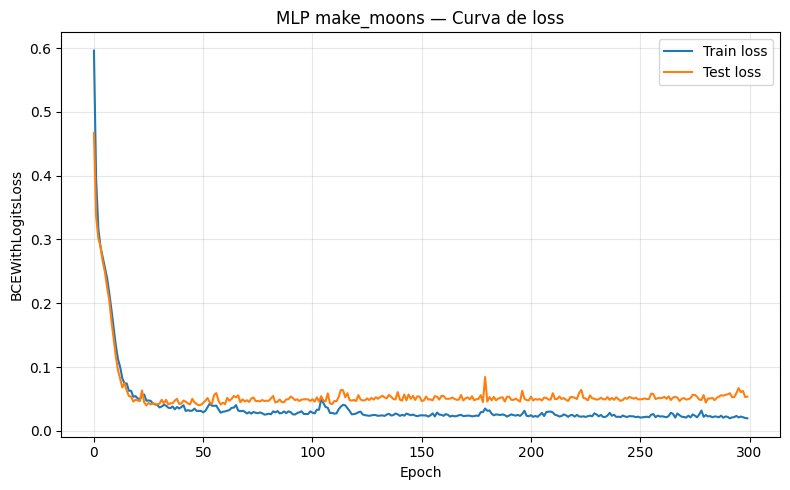

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(moon_history["train_loss"], label="Train loss")
plt.plot(moon_history["test_loss"], label="Test loss")

plt.title("MLP make_moons — Curva de loss")
plt.xlabel("Epoch")
plt.ylabel("BCEWithLogitsLoss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

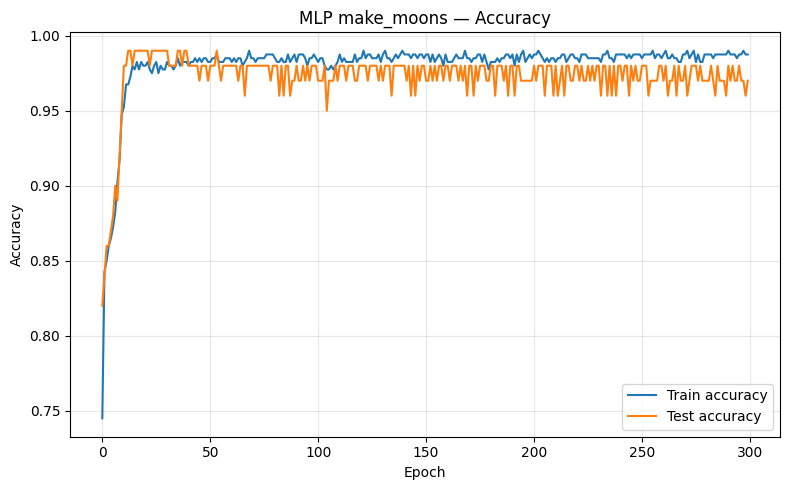

In [94]:
plt.figure(figsize=(8, 5))

plt.plot(moon_history["train_accuracy"], label="Train accuracy")
plt.plot(moon_history["test_accuracy"], label="Test accuracy")

plt.title("MLP make_moons — Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def plot_decision_boundary(
    model: nn.Module,
    scaler: StandardScaler,
    x_raw: np.ndarray,
    y_raw: np.ndarray,
    device: torch.device,
) -> None:
    """Grafica la frontera de decisión del modelo en el espacio original."""
    x_min, x_max = x_raw[:, 0].min() - 0.5, x_raw[:, 0].max() + 0.5
    y_min, y_max = y_raw[:, 1].min() - 0.5, y_raw[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )

    grid_raw = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid_raw)

    grid_tensor = torch.tensor(
        grid_scaled,
        dtype=torch.float32,
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(grid_tensor)
        probabilities = torch.sigmoid(logits)

    zz = probabilities.cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        zz,
        levels=30,
        alpha=0.7,
    )

    plt.contour(
        xx,
        yy,
        zz,
        levels=[0.5],
        linewidths=2,
    )

    plt.scatter(
        x_raw[:, 0],
        x_raw[:, 1],
        c=y_raw,
        s=25,
        edgecolors="k",
        alpha=0.8,
    )

    plt.title("Decision boundary — MLP en make_moons")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

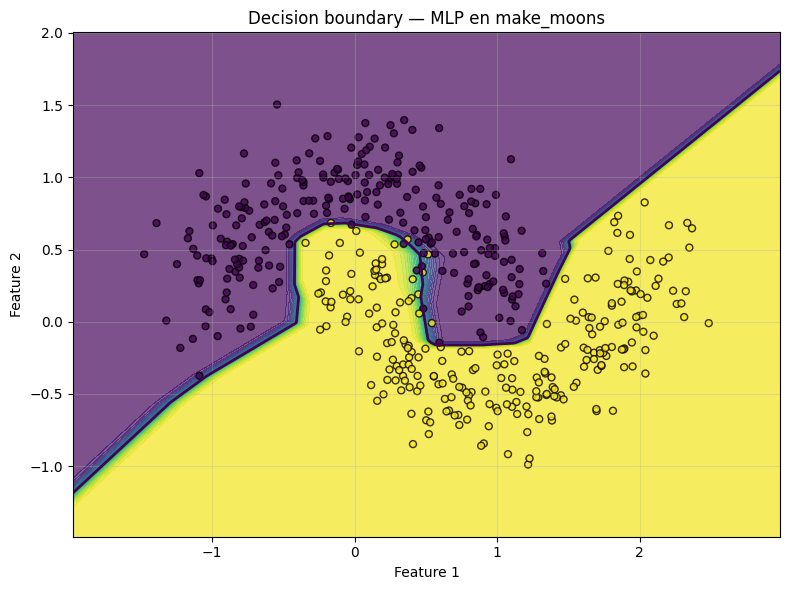

In [ ]:
plot_decision_boundary(
    model=moon_model,
    scaler=scaler_moons,
    x_raw=X_moons,
    y_raw=y_moons,
    device=DEVICE,
)

In [97]:
moon_model.eval()

with torch.no_grad():
    test_logits = moon_model(X_test_tensor.to(DEVICE))
    final_test_accuracy = binary_accuracy_from_logits(
        test_logits,
        y_test_tensor.to(DEVICE),
    )

print(f"Accuracy final en test: {final_test_accuracy:.4f}")

Accuracy final en test: 0.9700


### Conclusión de la Parte 5

En esta sección se entrenó un MLP para resolver un problema de clasificación binaria usando el dataset `make_moons`.

Este dataset no es linealmente separable, por lo que una frontera de decisión recta no sería suficiente. El MLP, al combinar capas lineales con activaciones ReLU, puede aprender transformaciones no lineales del espacio de entrada y construir una frontera de decisión curva.

El modelo se entrenó con `BCEWithLogitsLoss`, que es la opción recomendada para clasificación binaria cuando el modelo devuelve logits. En lugar de aplicar una sigmoid manualmente en la última capa, la función de pérdida combina internamente sigmoid y binary cross entropy de forma numéricamente estable.

La visualización del decision boundary muestra que la red aprendió una frontera no lineal capaz de separar adecuadamente las dos clases. Además, el accuracy final permite cuantificar el desempeño del modelo en el conjunto de prueba.

Este ejercicio conecta directamente con el entrenamiento de redes neuronales más grandes: aunque el modelo es pequeño, el patrón es el mismo que se usa en deep learning profesional:

1. Definir un modelo con `nn.Module`.
2. Preparar datos como tensores y mini-batches.
3. Calcular logits.
4. Calcular la pérdida.
5. Ejecutar `loss.backward()`.
6. Actualizar parámetros con `optimizer.step()`.
7. Evaluar el desempeño en datos no vistos.